In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_file = pd.read_csv('glass.txt', delimiter=r'\s+')
data = data_file[['RI', 'Al']]

np.random.seed(1023111157) # for reproducibility
data = data.iloc[np.random.permutation(len(data))].reset_index(drop=True)

x_data = data['Al'].values
y_data = data['RI'].values

In [3]:
class GaussianKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.x_data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)

    def __Gaussian_kernel(self, x):
        """Gaussian kernel function."""
        # Compute the Gaussian value for each element, no summation here
        return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

    def kernel(self, x, xi):
        """Applies the Gaussian kernel to the data."""
        # Element-wise calculation of Gaussian kernel
        return self.__Gaussian_kernel((x - xi) / self.bandwidth)

    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.kernel(point, self.x_data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)

In [4]:
def k_fold_error(kde, x_data, y_data, bandwidth, k:int = 10):
    
    data_length = int(len(x_data)/k)
    risk = 0
    for i in range(k):
        x_train = np.concatenate([x_data[:i*data_length], x_data[(i+1)*data_length:]])
        y_train = np.concatenate([y_data[:i*data_length], y_data[(i+1)*data_length:]])
        
        x_test = x_data[i*data_length:(i+1)*data_length]
        y_test = y_data[i*data_length:(i+1)*data_length]
        
        kernel = kde(bandwidth)
        kernel.fit(x_train, y_train)
        y_pred = kernel.predict(x_test)
        
        risk = risk + np.mean((y_pred - y_test) ** 2)
    
    risk = risk / k
    return risk

In [5]:
bandwidths_GaussianKDE = np.linspace(0.01, 2.01, 2000)

risks_Gkde = []
for bandwidth in bandwidths_GaussianKDE:
    risk = k_fold_error(GaussianKDE, x_data, y_data, bandwidth)
    # print(bandwidth, risk)
    risks_Gkde.append(risk)

best_bandwidth_Gkde = bandwidths_GaussianKDE[np.argmin(risks_Gkde)]
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth_Gkde}")

bandwidth corresponding to minimum estimated risk is 0.14406703351675837


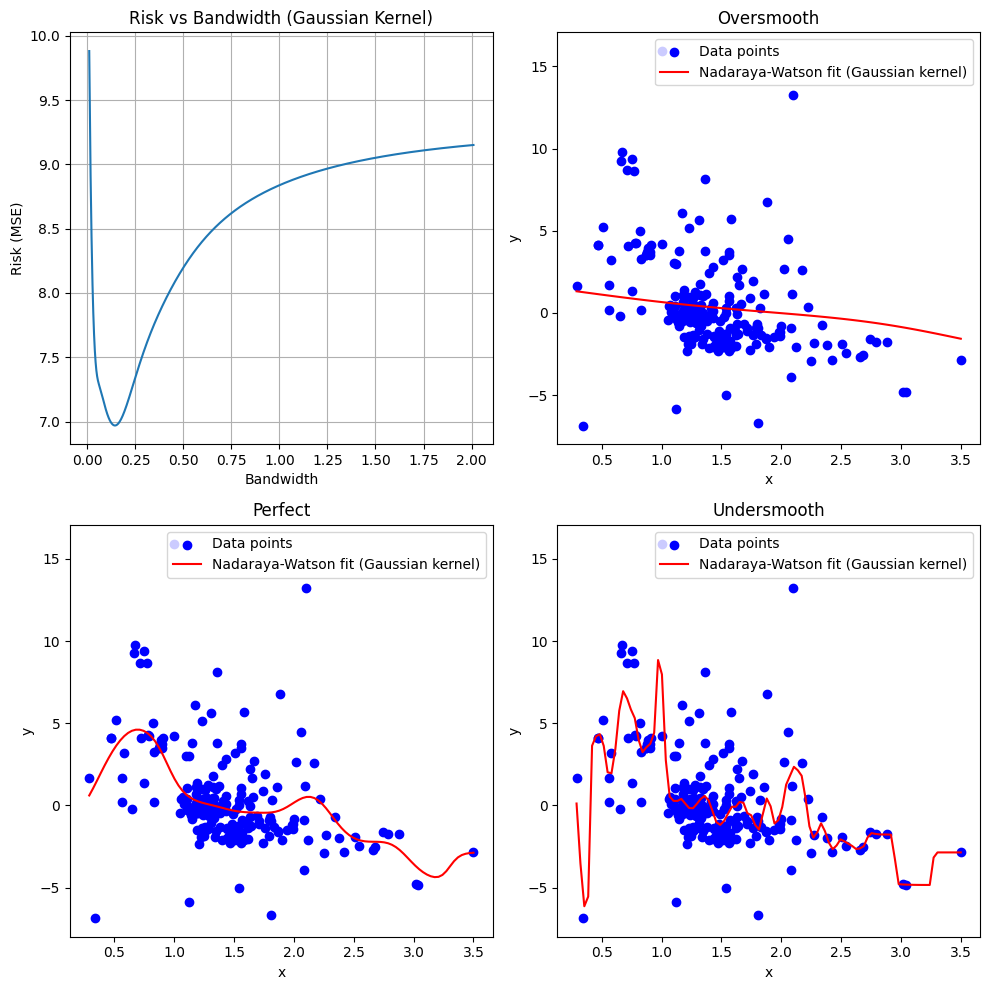

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_GaussianKDE, risks_Gkde)
# axs[0, 0].set_xlim([0, 1])
# axs[0, 0].set_ylim([4, 10])
axs[0, 0].set_title('Risk vs Bandwidth (Gaussian Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = GaussianKDE(bandwidth=best_bandwidth_Gkde * 5)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Gaussian kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = GaussianKDE(bandwidth=best_bandwidth_Gkde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Gaussian kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = GaussianKDE(bandwidth=best_bandwidth_Gkde / 5)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Gaussian kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig("Gaussian_kernel_regression.png")

plt.show()

In [7]:
class EpanechnikovKDE:
    def __init__(self, bandwidth=1.0):
        """Initialize the KDE model with the given bandwidth."""
        self.bandwidth = bandwidth
        self.x_data = None
        self.y_data = None

    def fit(self, x_data, y_data):
        """Fit the KDE model with the given x and y data."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)

    def __epanechnikov(self, x):
        return np.maximum(0, 0.75*(1-x**2))

    def epanechnikov_kernel(self, x, xi):
        """Epanechnikov kernel function."""
        return self.__epanechnikov((x-xi) / self.bandwidth)

    def predict(self, x):
        """Evaluate the Nadaraya-Watson estimator at points x."""
        func_val = []
        for point in x:
            weights = self.epanechnikov_kernel(point, self.x_data)
            numerator = np.sum(weights * self.y_data)
            denominator = np.sum(weights)
            
            if denominator > 0:
                func_val.append(numerator / denominator)
            else:
                func_val.append(0)  # Handle division by zero case
        return np.array(func_val)

In [8]:
bandwidths_EpanechnikovKDE = np.linspace(0.01, 2.01, 2000)
risks_Ekde = []
for bandwidth in bandwidths_EpanechnikovKDE:
    risk = k_fold_error(EpanechnikovKDE, x_data, y_data, bandwidth)
    # print(bandwidth, risk)
    risks_Ekde.append(risk)

best_bandwidth_Ekde = bandwidths_EpanechnikovKDE[np.argmin(risks_Ekde)]
print(f"bandwidth corresponding to minimum estimated risk is {best_bandwidth_Ekde}")

bandwidth corresponding to minimum estimated risk is 0.33016008004002


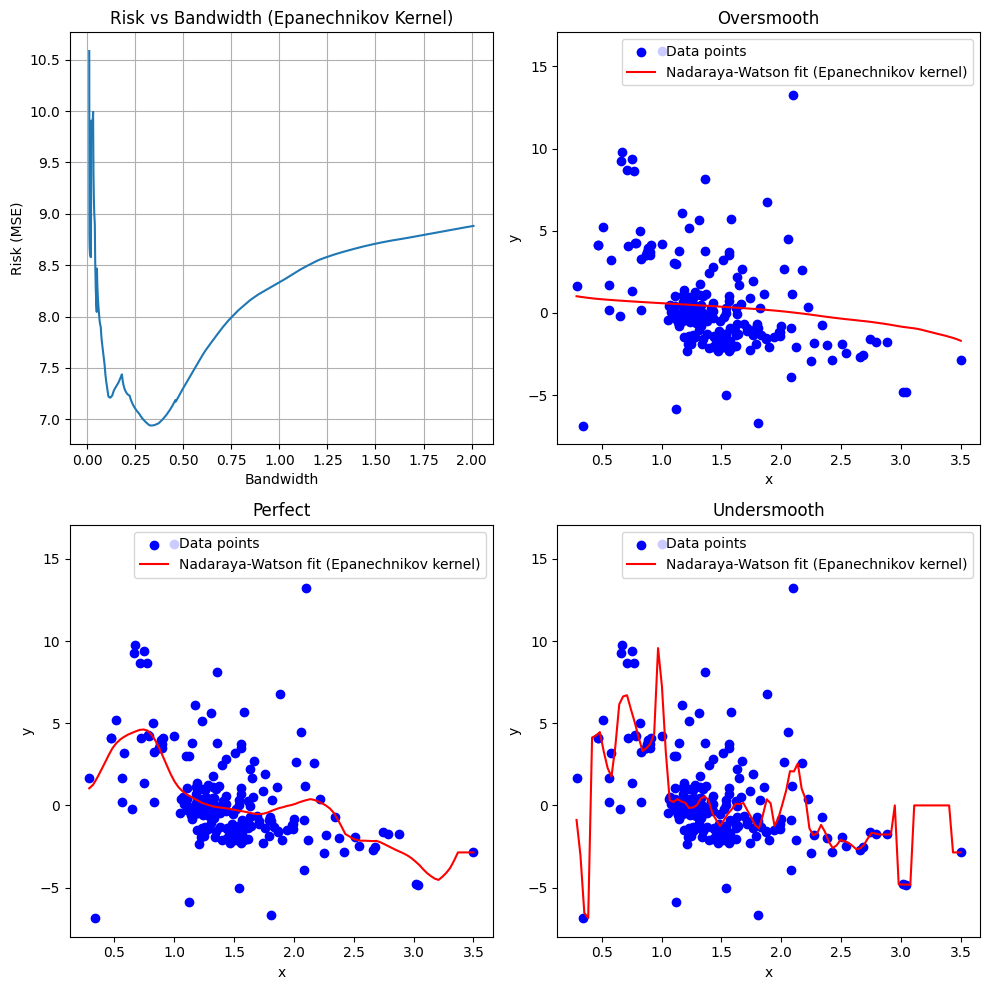

In [9]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot risk vs bandwidth
axs[0, 0].plot(bandwidths_EpanechnikovKDE, risks_Ekde)
axs[0, 0].set_title('Risk vs Bandwidth (Epanechnikov Kernel)')
axs[0, 0].set_xlabel('Bandwidth')
axs[0, 0].set_ylabel('Risk (MSE)')
axs[0, 0].grid(True)

# Oversmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde * 5)
kde.fit(x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = kde.predict(x_fit)
axs[0, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[0, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[0, 1].set_title('Oversmooth')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('y')
axs[0, 1].legend()

# perfect
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 0].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 0].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 0].set_title('Perfect')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('y')
axs[1, 0].legend()

# undersmooth
kde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde / 5)
kde.fit(x_data, y_data)
y_fit = kde.predict(x_fit)
axs[1, 1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1, 1].plot(x_fit, y_fit, color='red', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1, 1].set_title('Undersmooth')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig("epanechnikov_kernel_regression.png")

plt.show()

### Comparing Plots of both Estimates

<!-- 1. Can you empirically corroborate above statement using plots ? Are all kernel functions similarly dependent on choice of optimal bandwidth ? -->

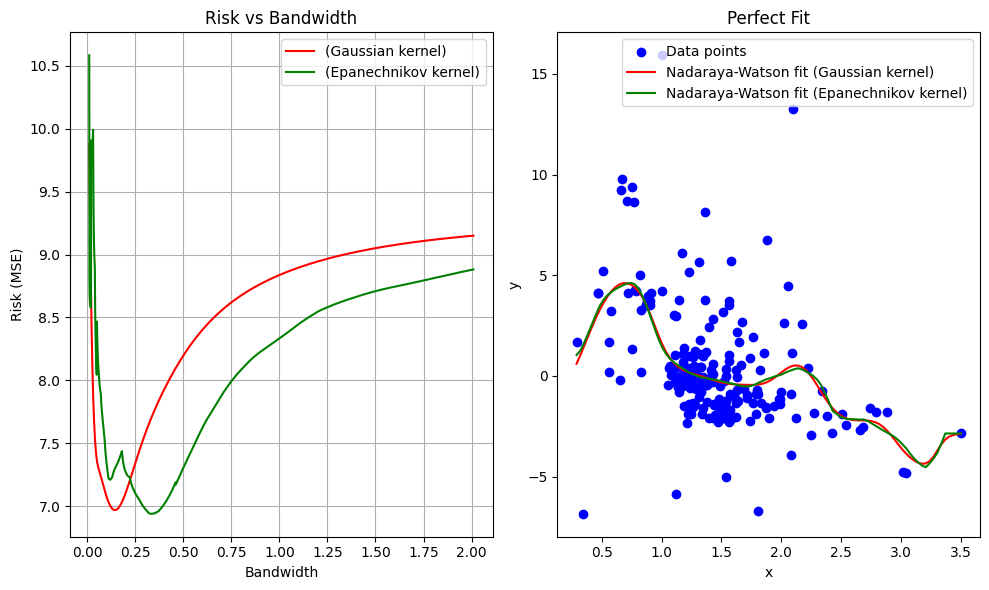

In [10]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

# Plot risk vs bandwidth
axs[0].plot(bandwidths_GaussianKDE, risks_Gkde, color='red', label='(Gaussian kernel)')
axs[0].plot(bandwidths_EpanechnikovKDE, risks_Ekde, color='green', label='(Epanechnikov kernel)')
axs[0].set_title('Risk vs Bandwidth')
axs[0].set_xlabel('Bandwidth')
axs[0].set_ylabel('Risk (MSE)')
axs[0].grid(True)
axs[0].legend()

# perfect
Ukde = GaussianKDE(bandwidth=best_bandwidth_Gkde)
Ukde.fit(x_data, y_data)
x_fitU = np.linspace(min(x_data), max(x_data), 100)
y_fitU = Ukde.predict(x_fit)

Ekde = EpanechnikovKDE(bandwidth=best_bandwidth_Ekde)
Ekde.fit(x_data, y_data)
x_fitE = np.linspace(min(x_data), max(x_data), 100)
y_fitE = Ekde.predict(x_fit)

axs[1].scatter(x_data, y_data, color='blue', label='Data points')
axs[1].plot(x_fitU, y_fitU, color='red', label='Nadaraya-Watson fit (Gaussian kernel)')
axs[1].plot(x_fitE, y_fitE, color='green', label='Nadaraya-Watson fit (Epanechnikov kernel)')
axs[1].set_title('Perfect Fit')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].legend()

plt.tight_layout()
plt.show()

## Is optimal bandwidth dependent on choice of kernel ?

In [11]:
best_bandwidth_Ekde, best_bandwidth_Gkde

(0.33016008004002, 0.14406703351675837)

Well, as we can see optimal bandwidth is highly dependent on the kernel being used.

## K-fold Cross-validation


In [12]:
# Re-shuffling of data
data = data.iloc[np.random.permutation(len(data))].reset_index(drop=True)

x_data_test = data['RI'].values
y_data_test = data['Al'].values

In [13]:
GaussianKDE_k_fold_error = k_fold_error(GaussianKDE, x_data_test, y_data_test, best_bandwidth_Gkde)
EpanechnikovKDE_k_fold_error = k_fold_error(EpanechnikovKDE, x_data_test, y_data_test, best_bandwidth_Ekde)

GaussianKDE_k_fold_error, EpanechnikovKDE_k_fold_error

(0.17972788714338148, 0.24444441065864866)

## Which is better by what margin ?

In [14]:
diff=2*(EpanechnikovKDE_k_fold_error - GaussianKDE_k_fold_error)/(GaussianKDE_k_fold_error + EpanechnikovKDE_k_fold_error)

if diff > 0:
    print(f"Gaussian KDE has {diff*100:.2f}% less error than Epanechnikov KDE.")
else:
    print(f"Epanechnikov KDE has {(-diff*100):.2f}% less error than Gaussian KDE.")

Gaussian KDE has 30.51% less error than Epanechnikov KDE.
